**В модуле 14 наша модель сгенерировала первый текст.** Все части трансформера собраны и работают. Но если поиграть с `generate.py` подольше, вы заметите две проблемы.

**Проблема 1: модель всегда отвечает одинаково**

*Запустите генерацию с одним и тем же промтом два, три, десять раз. Ответ будет совпадать до последнего символа.*

Все просто: наша функция `generate()` выбирает следующий токен через argmax - всегда самый вероятный. Одинаковый вход - одинаковый выход. Такой способ называется жадной генерацией (**greedy decoding**): на каждом шаге берём локально лучший токен и никогда не рискуем.

**Проблема 2: повторы и зацикливание**

Вторая проблема жадной генерации - склонность к повторам. Модель легко попадает в ловушку: после токена A самым вероятным оказывается B, после B - снова A, и текст начинает ходить по кругу:

`The cat was sleeping. The cat was sleeping. The cat was sleeping.`

Настоящие LLM страдают от этого точно так же - у проблемы есть название, **text degeneration** (вырождение текста). Термин ввели Holtzman и соавторы в статье «The Curious Case of Neural Text Degeneration» (2019) - в ней же предложен **top-p**, до которого мы дойдём. Вырождением называют оба края: и повторы жадной генерации, и бессмыслицу от слишком случайного выбора.

**Мы используем не всё, что знает модель**

Вспомните, что выдаёт модель: не «лучший токен», а **логиты по всему словарю** - а **softmax** превращает их в целое распределение вероятностей. В примере модуля 12 распределение выглядело так:

$$p \approx [0.153, 0.171, 0.360, 0.196, 0.120]$$

для словаря

$$["кот", "любил", "сметану", "он", "был"]$$

**Greedy берёт «сметану» (0.360) и выбрасывает остальные 64% вероятностной массы.**

А ведь распределение - это и есть «мнение» модели: она считает, что «он» - тоже неплохое продолжение (0.196), и «любил» возможно (0.171)!

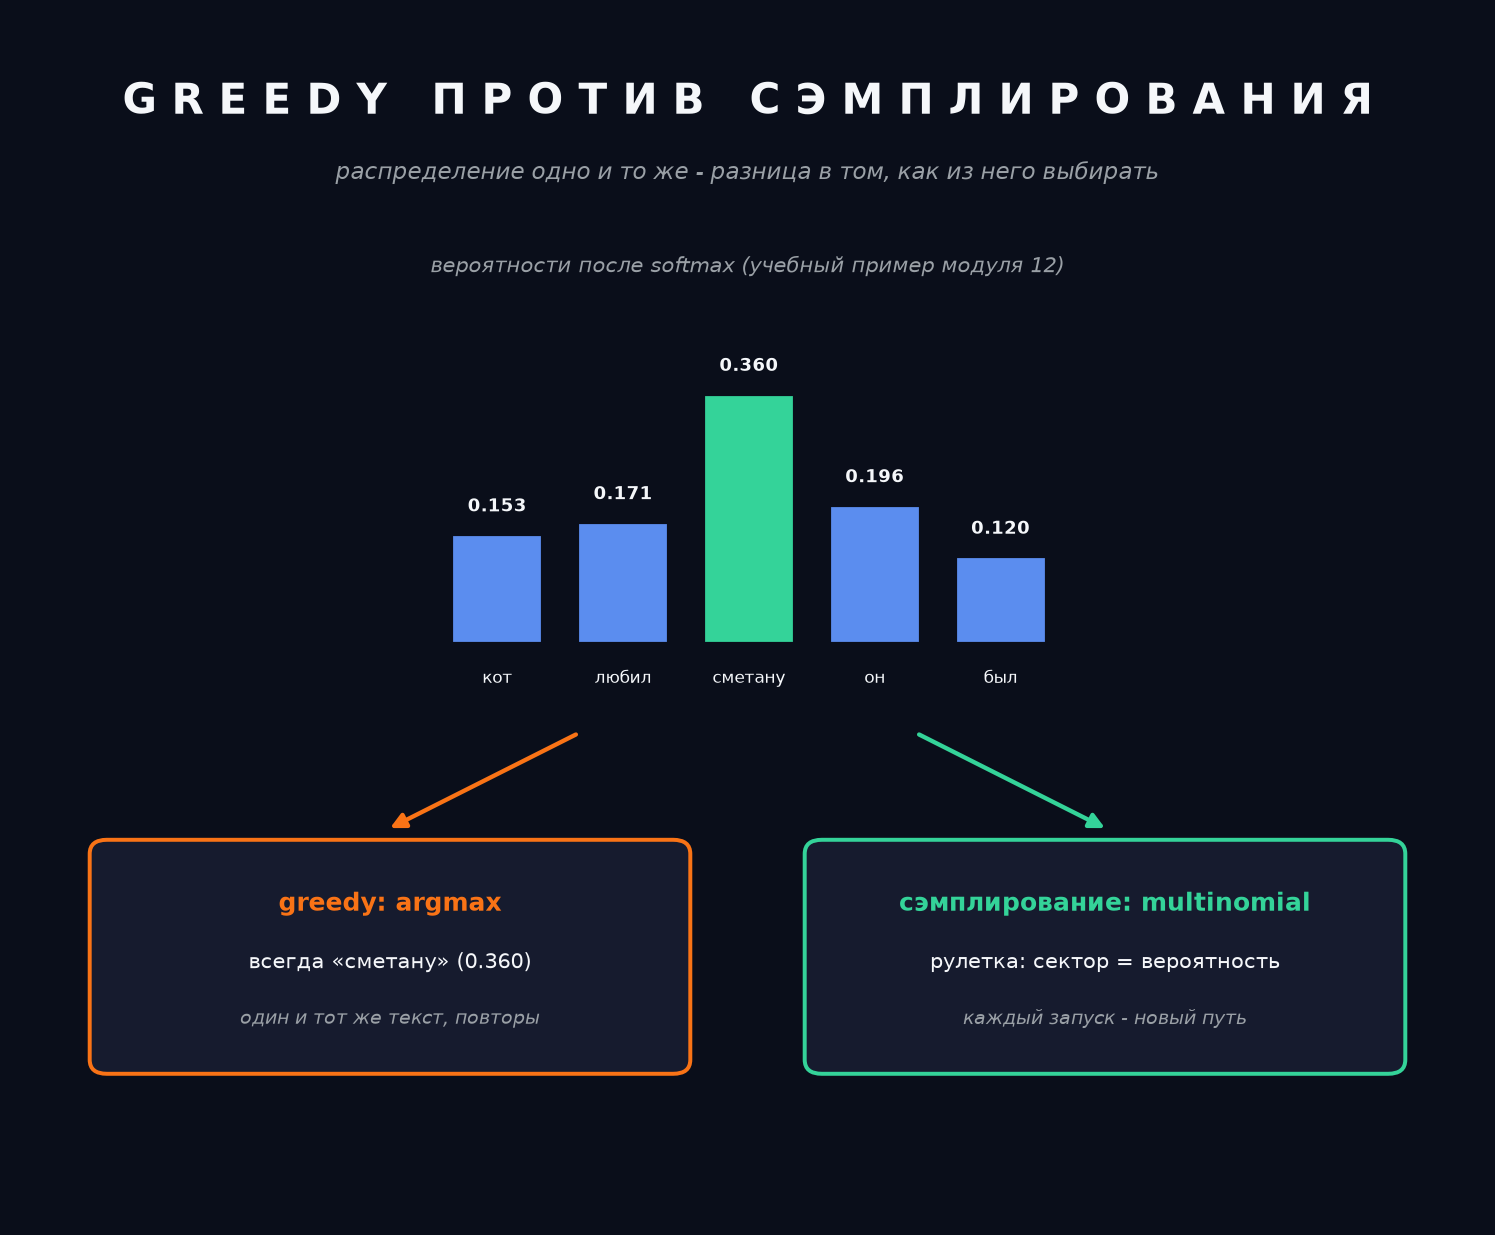

В этом модуле мы:
- научимся выбирать токен случайно, пропорционально вероятностям - это называется сэмплирование;
- добавим температуру - регулятор «предсказуемо/креативно», знакомый вам по модулю 2;
- отсечём мусорный хвост распределения: `top-k` и `top-p`;
- обновим `generate.py` и сравним все режимы на нашей обученной модели.

Сама модель при этом не меняется вообще: мы улучшаем только последний шаг - способ выбора следующего токена из готового распределения. Это те самые параметры `temperature`, `top_k` и `top_p`, которые вы видите в настройках любой современной LLM.

Вернёмся к примеру, где был словарь из 5 слов:
$$[кот, любил, сметану, он, был]$$
логиты:
$$logits = [0.085, 0.201, 0.944, 0.334, -0.155]$$
После softmax получили вероятности:
$$p \approx [0.153, 0.171, 0.360, 0.196, 0.120]$$

Жадная генерация всегда берёт «сметану» - у неё максимум. Но посмотрите на распределение внимательнее:

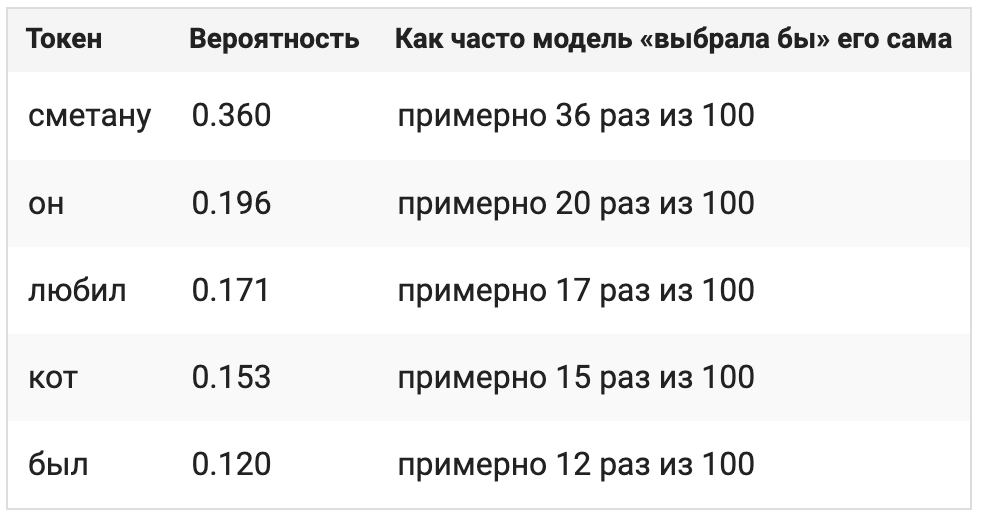

**Модель уверена в «сметану» только на 36%. В 64 случаях из 100 она сама предложила бы другое слово - а greedy эту информацию просто выбрасывает.**

### Сэмплирование - рулетка по вероятностям

**Сэмплирование (sampling)** - это выбор следующего токена случайно, пропорционально его вероятности.

Представьте рулетку, в которой каждому токену отведён сектор размером с его вероятность: у «сметану» - 36% круга, у «он» - 20%, у «был» - 12%. Крутим рулетку: куда попал шарик, тот токен и дописываем к тексту.

В PyTorch эта рулетка - одна функция, torch.multinomial:


`probs = torch.softmax(last_logits, dim=-1)            # логиты -> вероятности`

`next_token = torch.multinomial(probs, num_samples=1)  # тянем 1 токен по вероятностям`

Если крутить рулетку на нашем распределении 100 раз, «сметану» выпадет примерно 36 раз, «он» - примерно 20, и даже скромный «был» - примерно 12. Каждая генерация теперь может пойти своим путём, и все эти пути модель считает осмысленными.

* **Сэмплирование не делает модель умнее.** Все знания модели - в распределении вероятностей. Мы лишь начинаем пользоваться распределением целиком, а не одним его максимумом.
* **Случайность управляемая.** Чем выше вероятность токена, тем чаще он выпадает. Это не хаос, а честное следование «мнению» модели.
* **Обучение не меняется совсем.** Training loop, loss, градиенты - всё остаётся как в модуле 13. Сэмплирование живёт только внутри генерации.

Сэмплирование открыло дверь случайности. Теперь нужен регулятор: насколько смелой будет эта случайность. Он называется **температура**, и вы уже встречали его в модуле 2, когда разбирали softmax. Пришло время применить его к нашей модели.



**Формула:** Перед softmax делим все логиты на число $T$!

$$p_i = \frac{e^{z_i/T}}{\sum_{j} e^{z_j / T}}$$

* $T = 1$ - обычный softmax, ничего не меняется;
* $T < 1$ - различия между логитами усиливаются, распределение становится острее;
* $T > 1$ - различия сглаживаются, распределение становится ровнее.

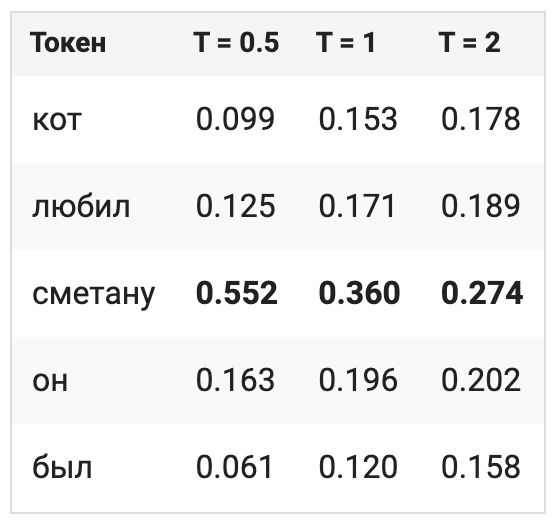

Из примера видно, что при $T = 0.5$ вероятность слова "сметана" увеличилась, а при $T = 2$ - уменьшилась (в этом же случае самая маленькая вероятность - увеличилась: распределение выравнивается)

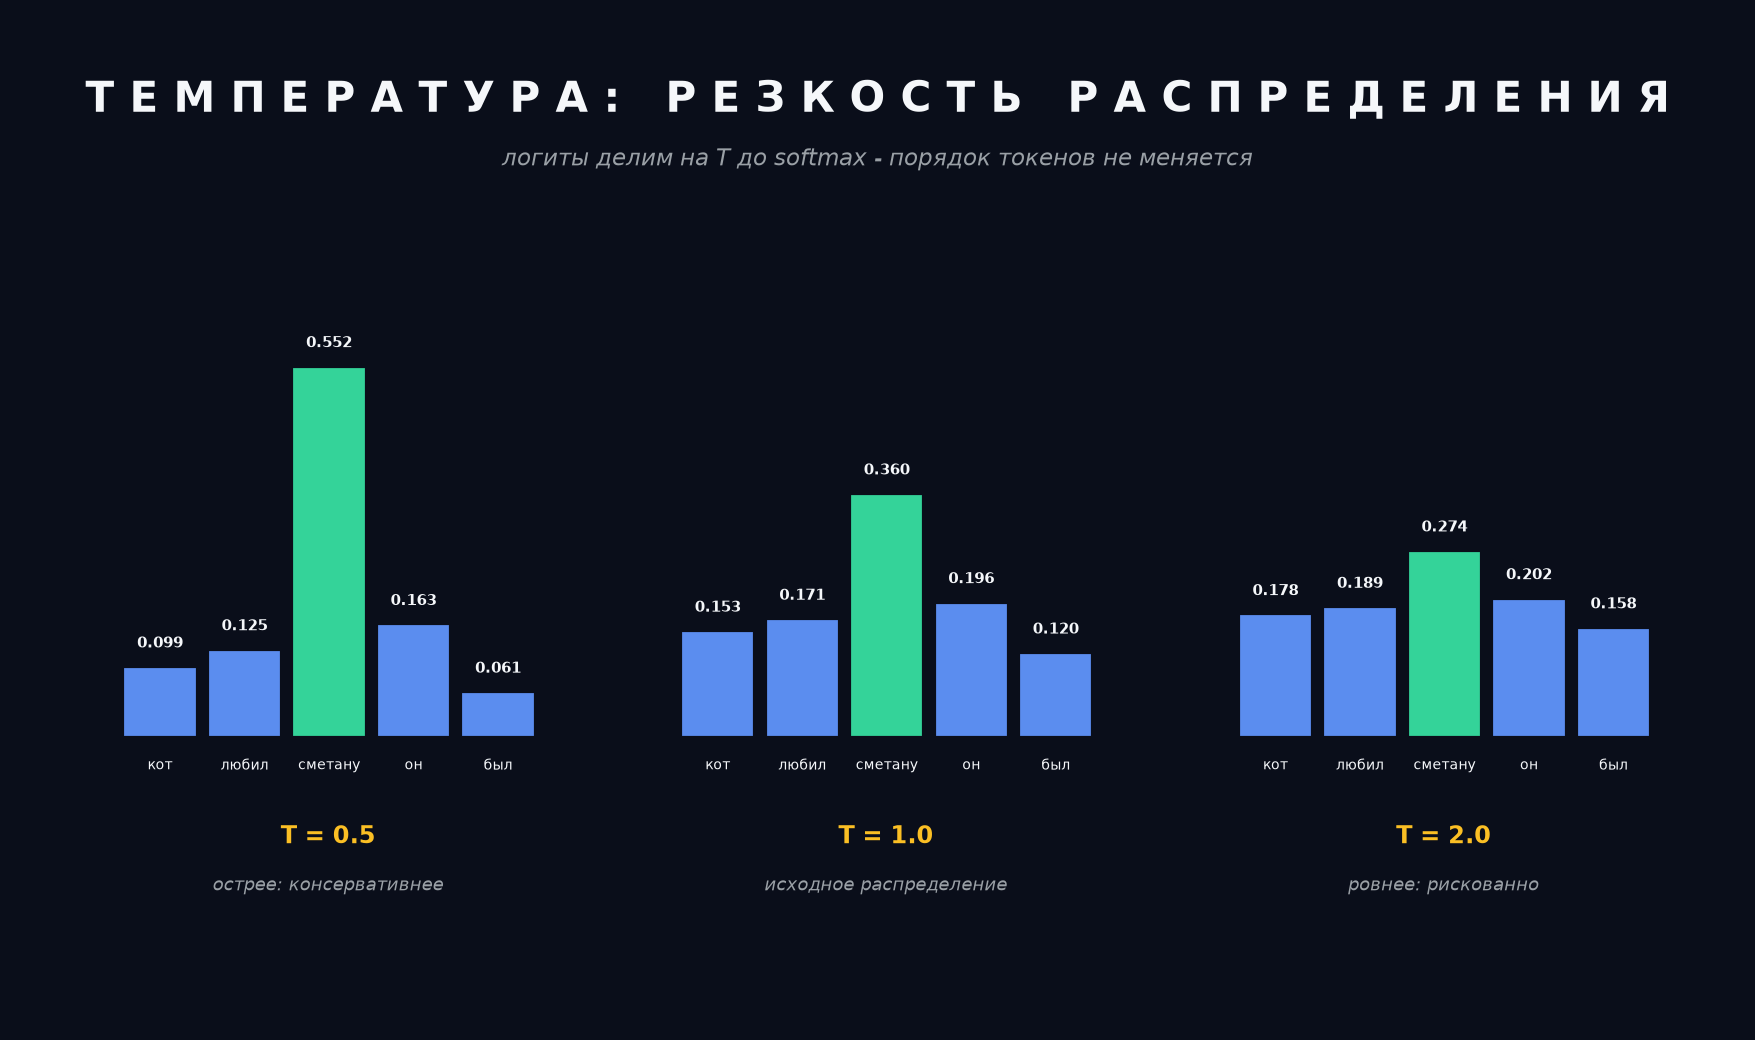

**Свойства температуры**

* **Порядок токенов не меняется.** При любой положительной T самый вероятный токен остаётся самым вероятным - меняются только расстояния между вероятностями.
* **Сумма вероятностей всегда равна 1** - softmax это гарантирует при любой T.
* **$T \rightarrow 0$**: почти вся вероятность достаётся максимуму, сэмплирование превращается в greedy. Это предел, а не рабочее значение: ровно ноль передавать нельзя, $T$ стоит в знаменателе. Нужен детерминированный вывод - берите обычный greedy
* **Очень большая $T$**: все токены почти равновероятны, текст превращается в случайный шум.

В настоящих LLM это тот самый параметр temperature из API. Типичный диапазон - **0.7-1.0**: чуть ниже единицы, чтобы текст был живым, но не разваливался.

**Температура с сэмплированием оживили генерацию, но открыли дверь мусору.**

В нашем учебном словаре всего 5 токенов, а в словаре GPT-2 их 50257. После softmax каждый из них получает ненулевую вероятность - в том числе тысячи токенов, которые вообще не подходят по смыслу. По отдельности их вероятности крошечные, но их очень много: хвост распределения в сумме набирает заметную массу. При температуре выше 1 хвост дополнительно подрастает, и рано или поздно рулетка вытаскивает полную чушь.

Одного неудачного токена достаточно, чтобы испортить всё продолжение: он попадает в контекст, и следующий шаг модель строит уже на нём.

### Идея top-k

Оставить в рулетке только $k$ самых вероятных токенов, остальных - отключить.

Отключаем знакомым способом: ставим логит -inf. Этот приём вы уже видели в causal mask $e^{-\infty} = 0$, поэтому после softmax отключённый токен получает вероятность строго ноль и выпасть в рулетке не может.

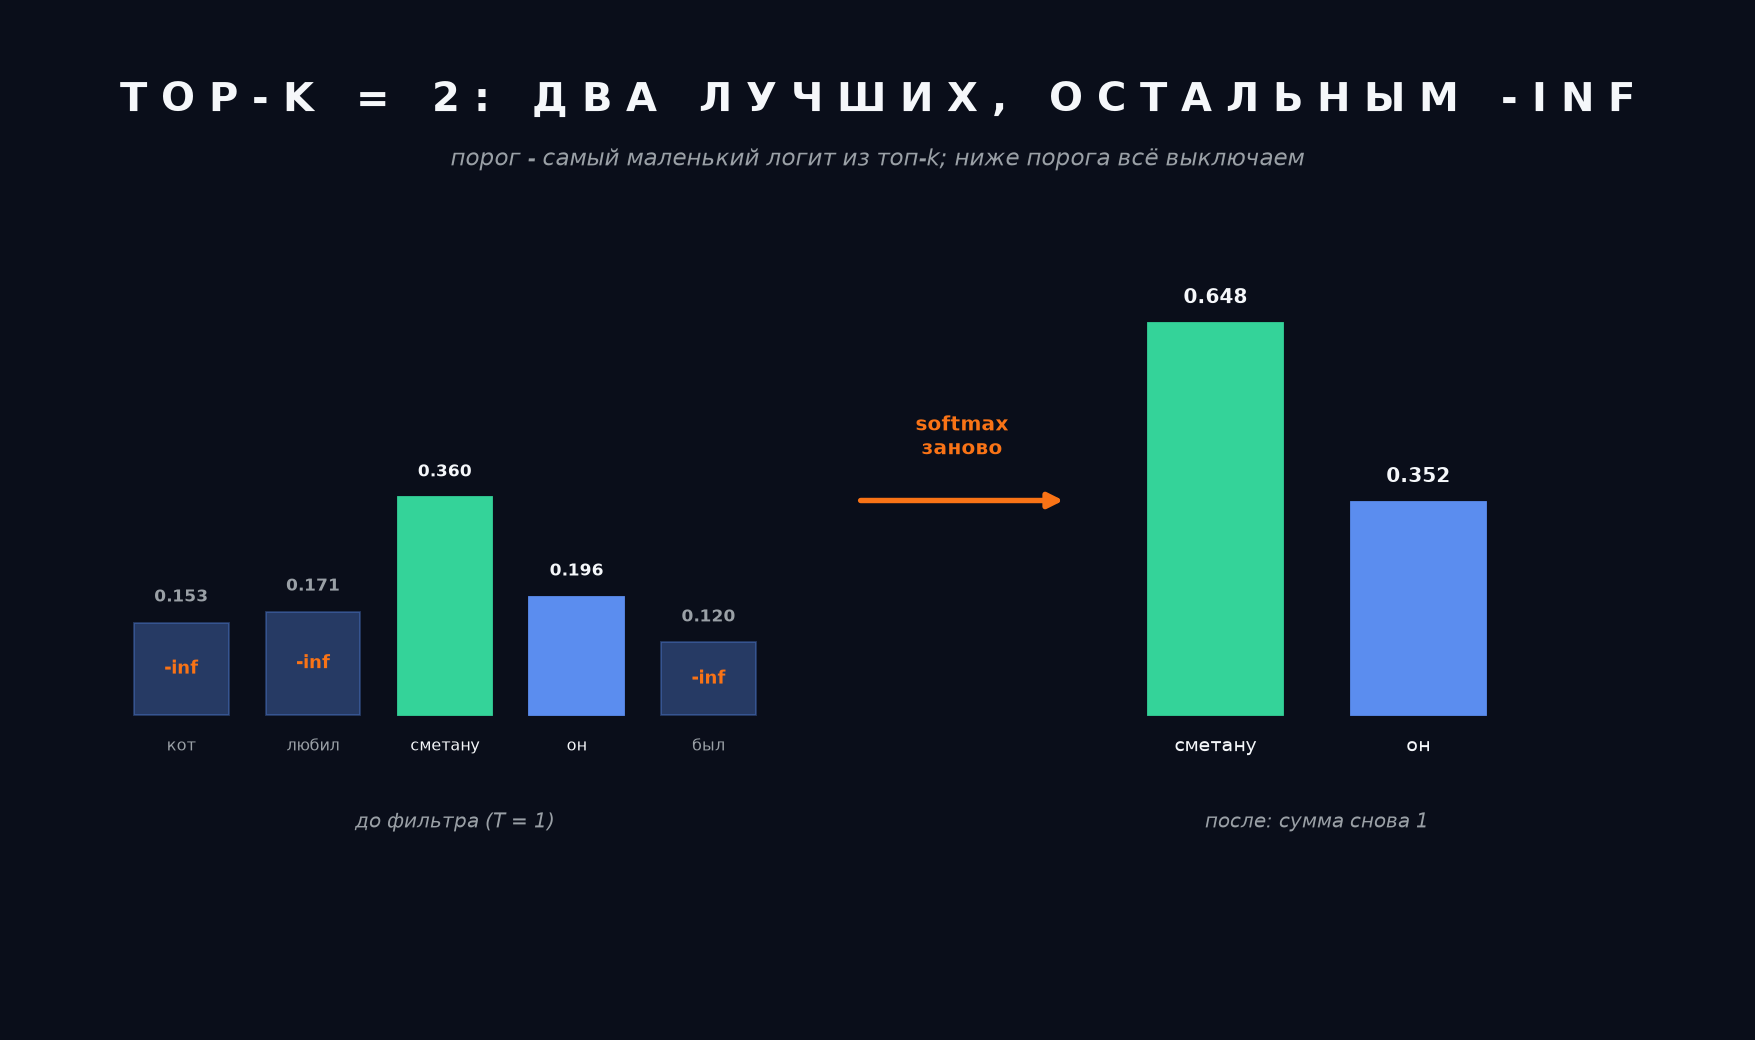

У **top-k** есть слабое место: $k$ одно на все случаи жизни, а уверенность модели меняется от шага к шагу.

* Иногда продолжение очевидно: после «Шёл сильный» почти вся вероятность у «дождь». Но top-k = 50 честно держит в рулетке 50 кандидатов, из которых 49 лишние. Их суммарная масса мала, и обычно рулетка всё равно берёт лидера, - но при высокой температуре стреляют именно эти лишние.
* Иногда хороших вариантов действительно много: после «Я люблю» осмысленных продолжений сотни, а top-k = 50 часть из них отрежет.

Хочется фильтр, который сам подстраивается под уверенность модели. Это **top-p**, он же **nucleus sampling** - сэмплирование из ядра.

### Идея top-p

Сортируем токены по убыванию вероятности и набираем «ядро»: добавляем токены по одному, пока их суммарная вероятность не достигнет порога $p$. Кто не попал в ядро - получает -inf, как в top-k.

**Важно!** После отбора нужно перенормировать вероятность - разделить на суммарную набранную вероятностную массу!

**Чем это лучше top-k**
Размер ядра плавает вместе с уверенностью модели:

- модель уверена (у лидера 90%) - ядро сжимается до 1-2 токенов;
- модель сомневается (вероятности размазаны) - ядро расширяется до десятков токенов.

Порог $p$ при этом один и тот же - на практике обычно 0.9-0.95.

Есть и обратная сторона той же адаптивности: **top-p** строит ядро по распределению, которое уже сглажено температурой. Если задрать T слишком высоко, ядро само расширится и мусор вернётся. Поэтому **top-p** сочетают с умеренной температурой.

**Как это всё сочетается**

Температура настраивает форму распределения, **top-k** и **top-p** отрезают хвост, рулетка выбирает токен. В API настоящих LLM вы видите ровно эти ручки: `temperature`, `top_k`, `top_p`. Теперь вы знаете, какая математика за ними стоит - и она вся умещается в несколько строк кода. В следующем уроке перенесём её в наш проект.

Весь новый код уложится в один маленький файл и пару правок в `generate.py`.

Создадим новый файл `sampling.py`.

Начнём с главной функции - выбора следующего токена. Пока без фильтров, только то, что мы уже разобрали: жадный режим, рулетка и температура!


Осталось подключить сэмплирование к настоящей генерации - обновляем `generate.py`.

Изменения три:

1. функция `generate()` получает новые параметры и передаёт их в `sample_next_token`;
2. заодно исправляем тонкую ошибку модуля 14: раньше внутри цикла мы обрезали саму последовательность `input_ids` до `max_length`, поэтому в конце декодировали только последние `max_length + 1 = 5` токенов - промт и начало текста терялись. Теперь обрезаем только `context` - то, что видит модель на текущем шаге, - а полную последовательность сохраняем;
3. при загрузке весов пишем `weights_only=True` явно. Это безопасный режим `torch.load`: он разрешает распаковать только веса и простые типы, а не произвольный код на Python. Начиная с torch 2.6 такое поведение стоит по умолчанию, но с явным флагом код одинаково работает на любой версии.